In [ ]:
import pandas as pd


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the CSV file
stock_data = pd.read_csv('/content/drive/MyDrive/all_stocks_5yr.csv')

In [ ]:
# Display the first few rows of the dataframe
stock_data.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [ ]:
# Display the summary information
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


In [ ]:
# Display shape of the dataset
stock_data.shape

(619040, 7)

In [ ]:
# Descriptive Statistics
print("\nDescriptive Statistics:")
print(stock_data.describe())


Descriptive Statistics:
                open           high            low          close  \
count  619029.000000  619032.000000  619032.000000  619040.000000   
mean       83.023334      83.778311      82.256096      83.043763   
std        97.378769      98.207519      96.507421      97.389748   
min         1.620000       1.690000       1.500000       1.590000   
25%        40.220000      40.620000      39.830000      40.245000   
50%        62.590000      63.150000      62.020000      62.620000   
75%        94.370000      95.180000      93.540000      94.410000   
max      2044.000000    2067.990000    2035.110000    2049.000000   

             volume  
count  6.190400e+05  
mean   4.321823e+06  
std    8.693610e+06  
min    0.000000e+00  
25%    1.070320e+06  
50%    2.082094e+06  
75%    4.284509e+06  
max    6.182376e+08  


In [ ]:
# Check for missing values
print(stock_data.isnull().sum())

date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64


In [ ]:
# Drop rows with any missing values
cleaned_stock_data = stock_data.dropna()

In [ ]:
# Checking for missing values again
print(cleaned_stock_data.isnull().sum())
print(cleaned_stock_data.info())

date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 619029 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619029 non-null  object 
 1   open    619029 non-null  float64
 2   high    619029 non-null  float64
 3   low     619029 non-null  float64
 4   close   619029 non-null  float64
 5   volume  619029 non-null  int64  
 6   Name    619029 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 37.8+ MB
None


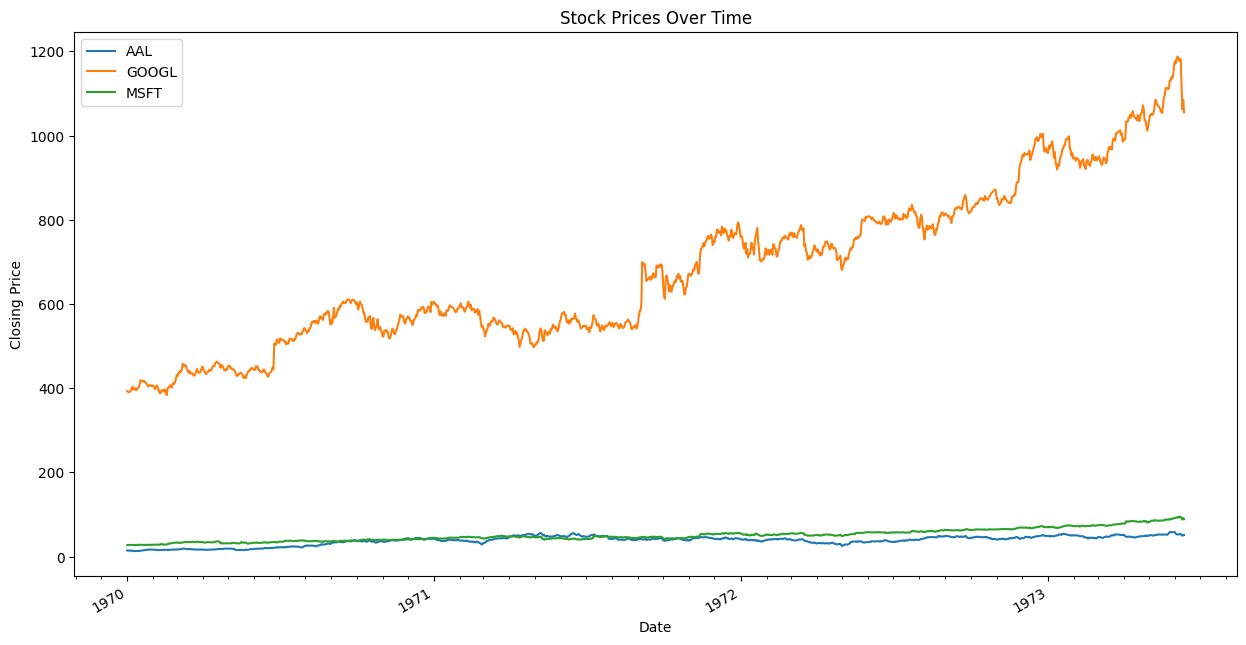

In [ ]:
# Data Visualization
# Plotting stock prices over time for a few selected stocks
selected_stocks = ['AAL', 'GOOGL', 'MSFT']
plt.figure(figsize=(15, 8))  # Increased figure size
for stock in selected_stocks:
    subset = stock_data[stock_data['Name'] == stock]
    plt.plot(subset['date'], subset['close'], label=stock)
plt.title('Stock Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()

# Improve x-axis ticks and labels
plt.gcf().autofmt_xdate()  # Automatically format x-axis labels
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # Set major ticks to yearly
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Show only the year
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())
plt.show()

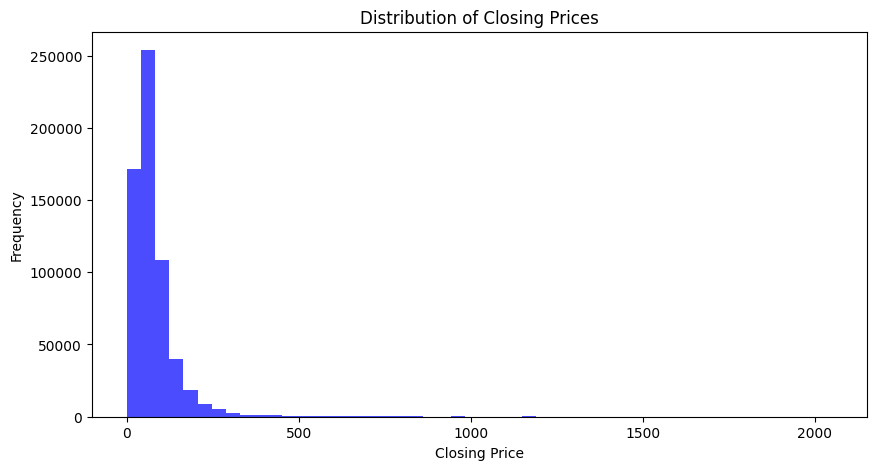

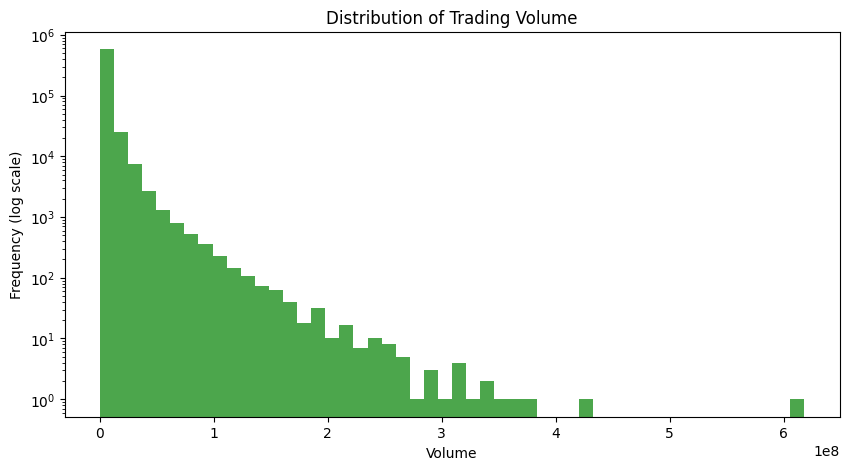

In [ ]:
# Histograms of closing prices and volumes
plt.figure(figsize=(10, 5))
plt.hist(stock_data['close'], bins=50, alpha=0.7, color='blue')
plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(stock_data['volume'], bins=50, alpha=0.7, color='green', log=True)
plt.title('Distribution of Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency (log scale)')
plt.show()

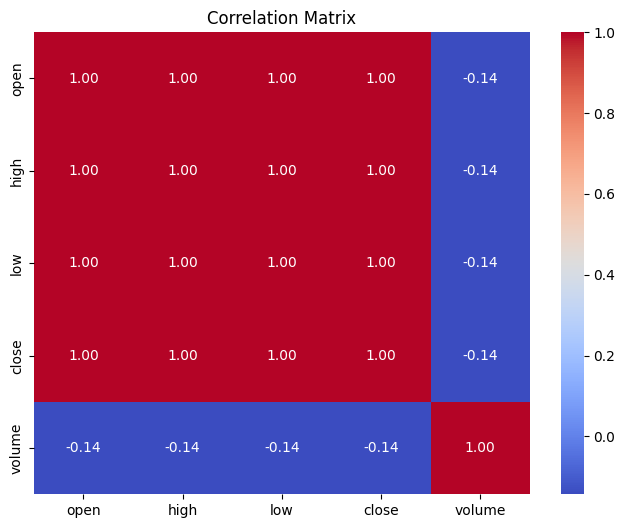

In [ ]:
# Correlation Matrix
plt.figure(figsize=(8, 6))
correlation_matrix = stock_data[['open', 'high', 'low', 'close', 'volume']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

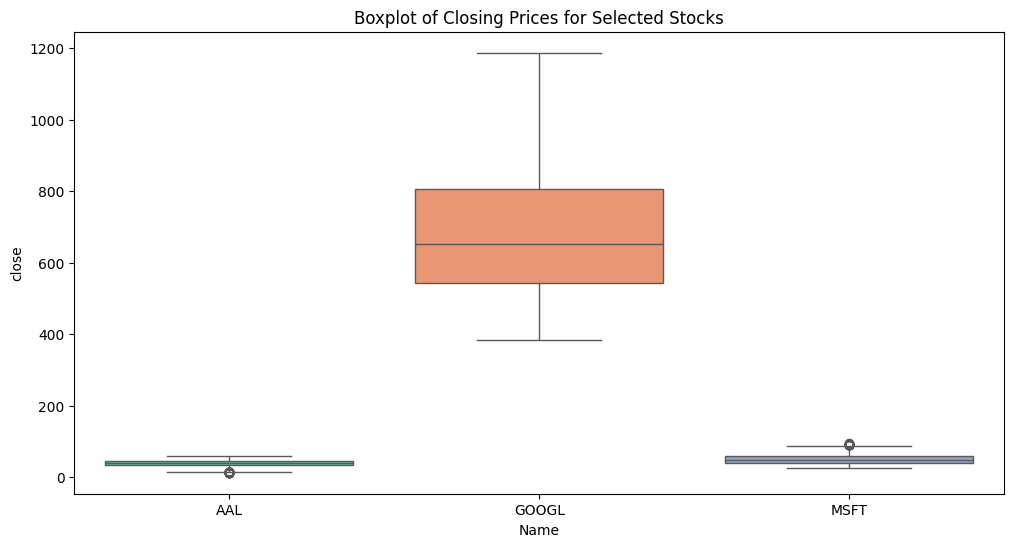

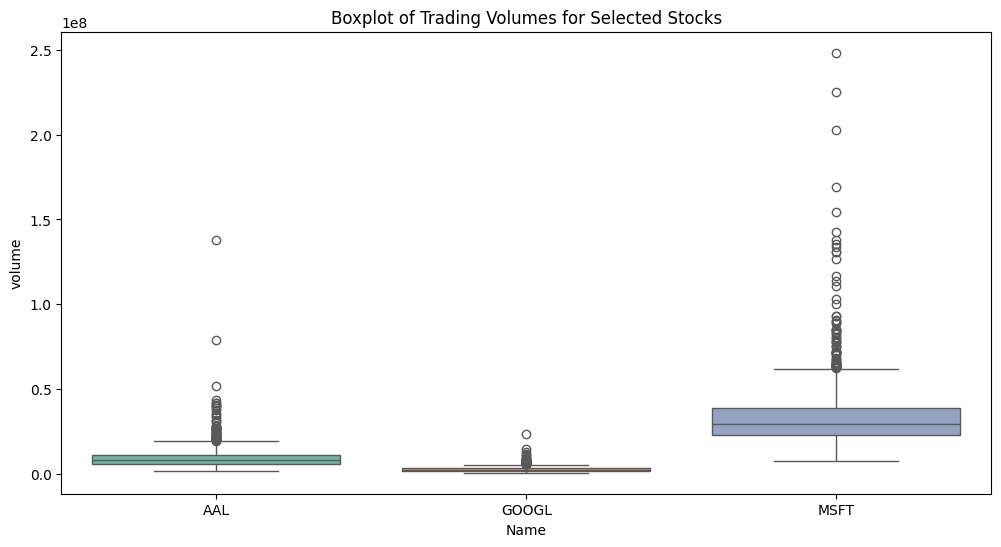

In [ ]:
# Boxplots for closing prices and volumes by stock
# Boxplot for closing prices of selected stocks
plt.figure(figsize=(12, 6))
sns.boxplot(x='Name', y='close', palette='Set2', hue='Name', data=stock_data[stock_data['Name'].isin(selected_stocks)])
plt.title('Boxplot of Closing Prices for Selected Stocks')
plt.show()

# Boxplot for volumes of selected stocks
plt.figure(figsize=(12, 6))
sns.boxplot(x='Name', y='volume', palette='Set2', hue='Name', data=stock_data[stock_data['Name'].isin(selected_stocks)])
plt.title('Boxplot of Trading Volumes for Selected Stocks')
plt.show()

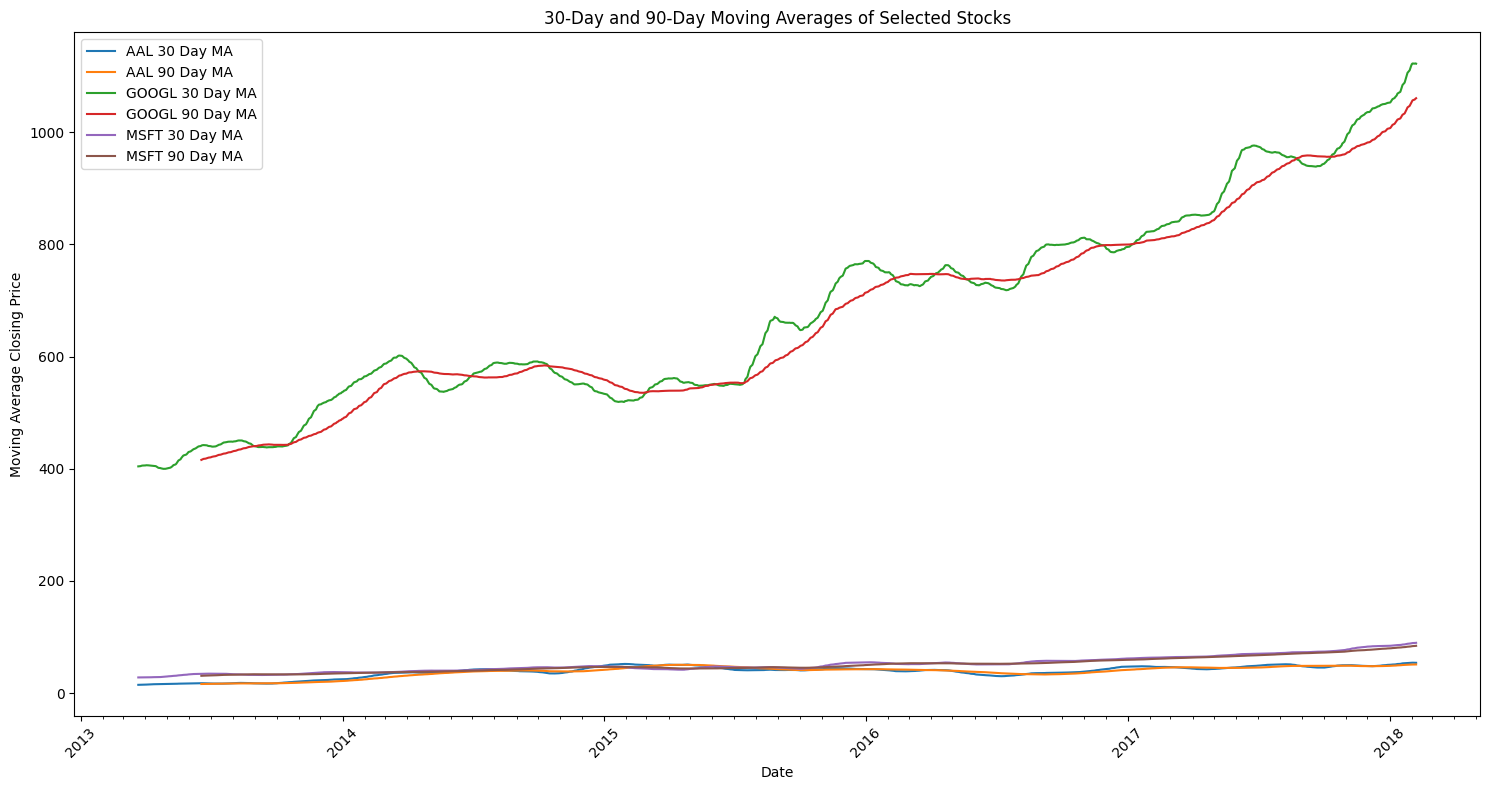

In [ ]:
# Seasonality Analysis (Average monthly closing prices)
stock_data['date'] = pd.to_datetime(stock_data['date'])

selected_stocks = ['AAL', 'GOOGL', 'MSFT']  # List of selected stocks
sample_stocks = stock_data[stock_data['Name'].isin(selected_stocks)].copy()

# Calculate moving averages for the closing price of selected stocks
sample_stocks['30_day_ma'] = sample_stocks.groupby('Name')['close'].transform(lambda x: x.rolling(window=30).mean())
sample_stocks['90_day_ma'] = sample_stocks.groupby('Name')['close'].transform(lambda x: x.rolling(window=90).mean())

# Calculate daily returns for volatility analysis
sample_stocks['daily_returns'] = sample_stocks.groupby('Name')['close'].pct_change()

# Plotting moving averages with improved date readability
plt.figure(figsize=(15, 8))  # Increased figure size for better readability
for label, df in sample_stocks.groupby('Name'):
    df = df.sort_values('date')  # Ensure the dates are sorted
    plt.plot(df['date'], df['30_day_ma'], label=f'{label} 30 Day MA')
    plt.plot(df['date'], df['90_day_ma'], label=f'{label} 90 Day MA')

# Format the date to make it more readable
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # Locate ticks every year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Show only the year
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())  # Optional: Minor ticks every month

plt.title('30-Day and 90-Day Moving Averages of Selected Stocks')
plt.xlabel('Date')
plt.ylabel('Moving Average Closing Price')
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels to avoid overlap
plt.tight_layout()  # Adjust layout
plt.show()

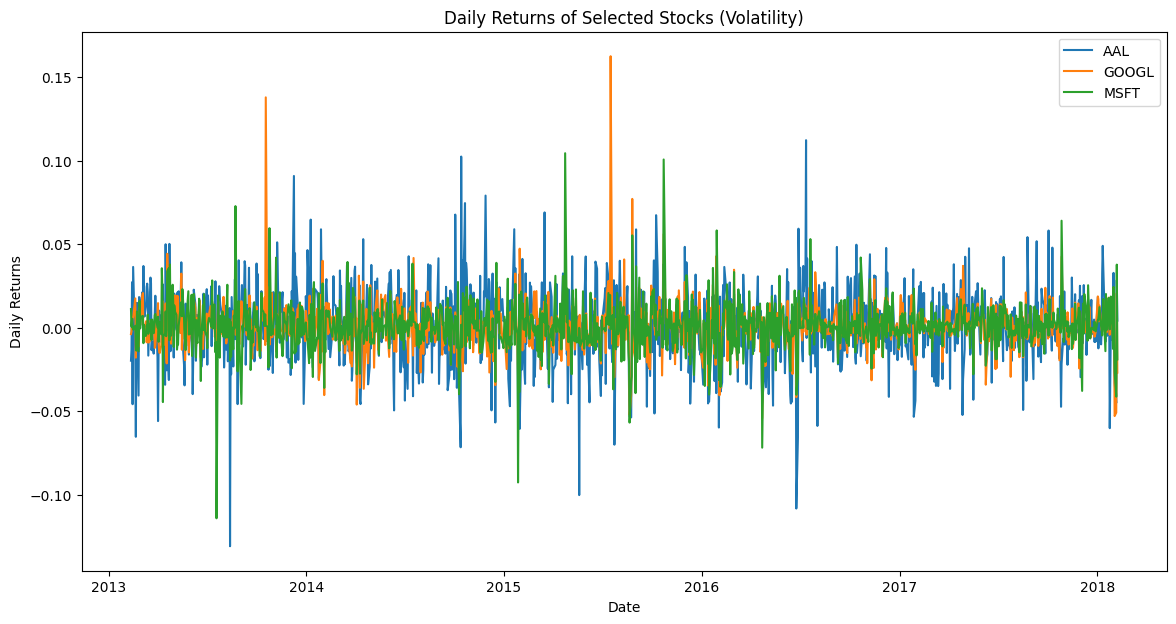

In [ ]:
# Plotting volatility
plt.figure(figsize=(14, 7))
for label, df in sample_stocks.groupby('Name'):
    plt.plot(df['date'], df['daily_returns'], label=label)
plt.title('Daily Returns of Selected Stocks (Volatility)')
plt.xlabel('Date')
plt.ylabel('Daily Returns')
plt.legend()
plt.show()

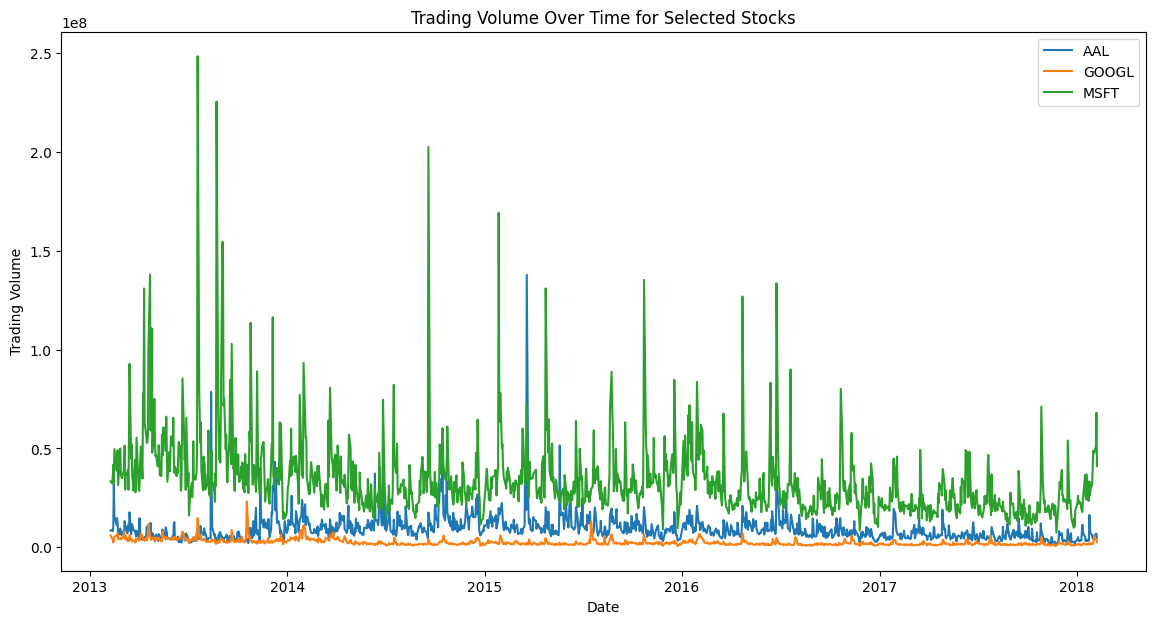

In [ ]:
# Market behavior - Trading Volume Over Time for Selected Stocks
plt.figure(figsize=(14, 7))
for label, df in sample_stocks.groupby('Name'):
    plt.plot(df['date'], df['volume'], label=label)
plt.title('Trading Volume Over Time for Selected Stocks')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.legend()
plt.show()

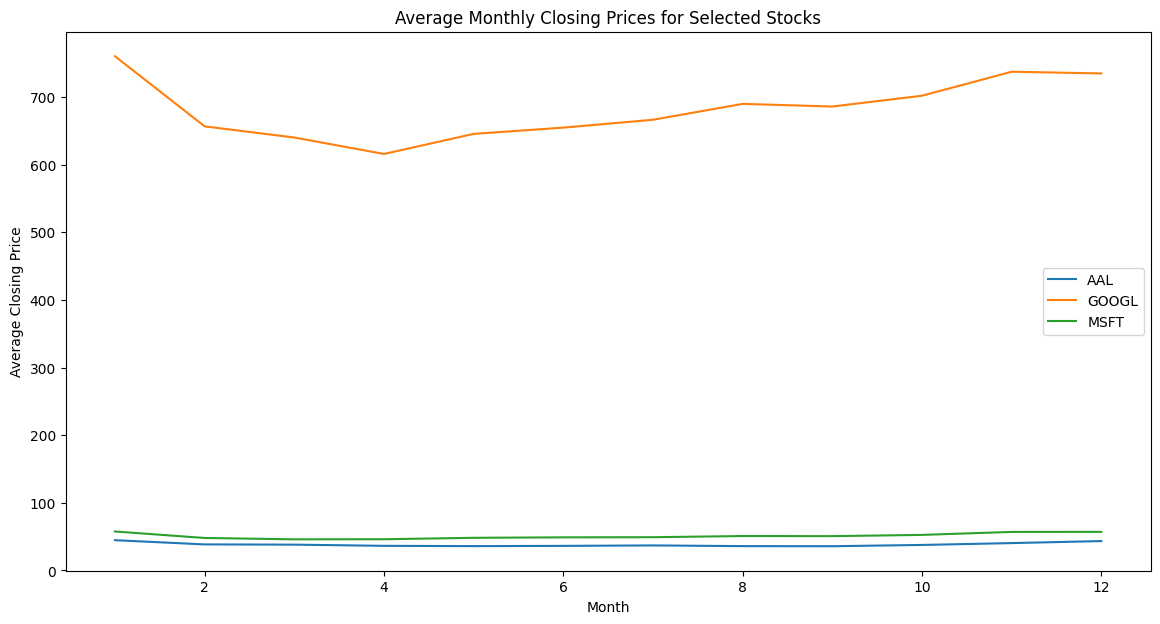

In [ ]:
# Extract month from the date for seasonality analysis
sample_stocks['month'] = sample_stocks['date'].dt.month

# Group by stock and month to calculate average closing prices per month
monthly_averages = sample_stocks.groupby(['Name', 'month'])['close'].mean().unstack()

# Plotting average monthly closing prices for each stock
plt.figure(figsize=(14, 7))
for stock in monthly_averages.index:
    plt.plot(monthly_averages.columns, monthly_averages.loc[stock], label=stock)
plt.title('Average Monthly Closing Prices for Selected Stocks')
plt.xlabel('Month')
plt.ylabel('Average Closing Price')
plt.legend()
plt.show()

In [ ]:
# Using Microsoft (MSFT)
msft_data = cleaned_stock_data[cleaned_stock_data['Name'] == 'MSFT'].copy()

# Sort data by date to ensure correct lag calculations
msft_data.sort_values('date', inplace=True)

# Create lagged returns
msft_data['lagged_1d_return'] = msft_data['close'].pct_change().shift(1)

# Drop any NaN values that were created by lagging the series
msft_data.dropna(inplace=True)

# Display the updated DataFrame to check the new feature
print(msft_data.head())

              date     open   high     low   close    volume  Name  \
390200  2013-02-12  27.8800  28.00  27.750  27.880  35990829  MSFT   
390201  2013-02-13  27.9300  28.11  27.880  28.030  41715530  MSFT   
390202  2013-02-14  27.9200  28.06  27.870  28.040  32663174  MSFT   
390203  2013-02-15  28.0400  28.16  27.875  28.010  49650538  MSFT   
390204  2013-02-19  27.8801  28.09  27.800  28.045  38804616  MSFT   

        lagged_1d_return  
390200          0.011252  
390201          0.000718  
390202          0.005380  
390203          0.000357  
390204         -0.001070  


In [ ]:
# Selecting features and target variable
X = msft_data[['lagged_1d_return']]  # Feature: previous day's return
y = msft_data['close']               # Target: today's close price

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predict on the testing set
y_pred = linear_model.predict(X_test)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the results
print("Root Mean Squared Error of Linear Regression:", rmse)
print("Mean Absolute Error of Linear Regression:", mae)
print("R-squared of Linear Regression:", r2)

Root Mean Squared Error of Linear Regression: 14.653826582071817
Mean Absolute Error of Linear Regression: 12.08154380047124
R-squared of Linear Regression: -0.004128370929086023


In [ ]:
# Initialize and train a Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Initialize and train a Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# Print the results
print("Root Mean Squared Error of Random Forest Regressor:", rmse_rf)
print("Mean Absolute Error of Random Forest Regressor:", mae_rf)
print("R-squared of Random Forest Regressor:", r2_rf)
print("Root Mean Squared Error of Gradient Boosting Regressor:", rmse_gb)
print("Mean Absolute Error of Gradient Boosting Regressor:", mae_gb)
print("R-squared of Gradient Boosting Regressor:", r2_gb)

Root Mean Squared Error of Random Forest Regressor: 17.685976773301334
Mean Absolute Error of Random Forest Regressor: 14.082262533708578
R-squared of Random Forest Regressor: -0.46266625944456674
Root Mean Squared Error of Gradient Boosting Regressor: 14.87495161121712
Mean Absolute Error of Gradient Boosting Regressor: 12.0531641820385
R-squared of Gradient Boosting Regressor: -0.03466144444513786


In [ ]:
# Calculate with additional technical indicators
# Moving Averages
msft_data['ma7'] = msft_data['close'].rolling(window=7).mean()
msft_data['ma21'] = msft_data['close'].rolling(window=21).mean()

# RSI
delta = msft_data['close'].diff()
gain = (delta.where(delta > 0, 0)).fillna(0)
loss = (-delta.where(delta < 0, 0)).fillna(0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
msft_data['rsi'] = 100 - (100 / (1 + rs))

# MACD
exp1 = msft_data['close'].ewm(span=12, adjust=False).mean()
exp2 = msft_data['close'].ewm(span=26, adjust=False).mean()
msft_data['macd'] = exp1 - exp2
msft_data['signal'] = msft_data['macd'].ewm(span=9, adjust=False).mean()

# Dropping rows with NaN values created by rolling means and EWM
msft_data.dropna(inplace=True)

# Display the updated DataFrame with new features
msft_data[['close', 'lagged_1d_return', 'ma7', 'ma21', 'rsi', 'macd', 'signal']].tail()

,close,lagged_1d_return,ma7,ma21,rsi,macd,signal
391452,94.26,0.024477,93.448571,90.470952,73.303167,2.176741,1.910506
391453,91.78,-0.007894,93.442857,90.729524,57.665260,1.966352,1.921675
391454,88.00,-0.026310,92.824286,90.771905,48.955224,1.477570,1.832854
391455,91.33,-0.041185,92.434286,90.921429,53.253144,1.343424,1.734968
391456,89.61,0.037841,91.818571,90.984762,48.773160,1.085806,1.605136


In [ ]:
# Selecting new features and target variable
X_new = msft_data[['lagged_1d_return', 'ma7', 'ma21', 'rsi', 'macd', 'signal']]
y_new = msft_data['close']  # Target remains the same

# Split the new dataset into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

# Random Forest Regressor
rf_model_new = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_new.fit(X_train_new, y_train_new)
y_pred_rf_new = rf_model_new.predict(X_test_new)
rmse_rf_new = np.sqrt(mean_squared_error(y_test_new, y_pred_rf_new))
mae_rf_new = mean_absolute_error(y_test_new, y_pred_rf_new)
r2_rf_new = r2_score(y_test_new, y_pred_rf_new)

# Gradient Boosting Regressor
gb_model_new = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model_new.fit(X_train_new, y_train_new)
y_pred_gb_new = gb_model_new.predict(X_test_new)
rmse_gb_new = np.sqrt(mean_squared_error(y_test_new, y_pred_gb_new))
mae_gb_new = mean_absolute_error(y_test_new, y_pred_gb_new)
r2_gb_new = r2_score(y_test_new, y_pred_gb_new)

# Print the results
print("Root Mean Squared Error of Random Forest Regressor:", rmse_rf_new)
print("Mean Absolute Error of Random Forest Regressor:", mae_rf_new)
print("R-squared of Random Forest Regressor:", r2_rf_new)
print("Root Mean Squared Error of Gradient Boosting Regressor:", rmse_gb_new)
print("Mean Absolute Error of Gradient Boosting Regressor:", mae_gb_new)
print("R-squared of Gradient Boosting Regressor:", r2_gb_new)

Root Mean Squared Error of Random Forest Regressor: 0.6769580606391479
Mean Absolute Error of Random Forest Regressor: 0.44469568548387
R-squared of Random Forest Regressor: 0.9978290794862611
Root Mean Squared Error of Gradient Boosting Regressor: 0.7051359348831803
Mean Absolute Error of Gradient Boosting Regressor: 0.508598020894562
R-squared of Gradient Boosting Regressor: 0.997644592302382


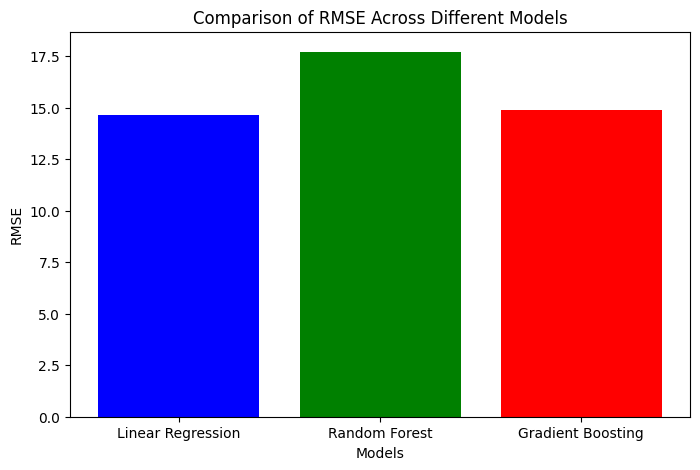

In [ ]:
# Comparing rmse value
rmse_values = {
    'Linear Regression': rmse,
    'Random Forest': rmse_rf,
    'Gradient Boosting': rmse_gb
}

# Creating a bar chart for RMSE
plt.figure(figsize=(8, 5))
plt.bar(rmse_values.keys(), rmse_values.values(), color=['blue', 'green', 'red'])
plt.title('Comparison of RMSE Across Different Models')
plt.xlabel('Models')
plt.ylabel('RMSE')
plt.ylim(0, max(rmse_values.values()) + 1)
plt.show()